<a href="https://colab.research.google.com/github/khushi947/CODSOFT/blob/main/Copy_of_Untitled16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Sample Images.zip to Sample Images.zip


In [ ]:
!unzip -q "Sample Images.zip" -d iron_ore_raw
!ls iron_ore_raw

replace iron_ore_raw/Sample Images/BDO-10x-Sample-01.tif? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
'Sample Images'


In [ ]:
!ls "iron_ore_raw/Sample Images"
!ls "iron_ore_raw/Sample Images" -R | head -50

BDO-10x-Sample-01.tif  HLO-20x-Sample-05.jpg  LO-20x-Sample-09.jpg
BDO-10x-Sample-02.tif  HLO-20x-Sample-06.jpg  LO-20x-Sample-10.jpg
HLO-10x-Sample-03.tif  LO-10x-Sample-07.tif   SLO-10x-Sample-11.tif
HLO-10x-Sample-04.tif  LO-10x-Sample-08.tif   SLO-10x-Sample-12.tif
iron_ore_raw/Sample Images:
BDO-10x-Sample-01.tif
BDO-10x-Sample-02.tif
HLO-10x-Sample-03.tif
HLO-10x-Sample-04.tif
HLO-20x-Sample-05.jpg
HLO-20x-Sample-06.jpg
LO-10x-Sample-07.tif
LO-10x-Sample-08.tif
LO-20x-Sample-09.jpg
LO-20x-Sample-10.jpg
SLO-10x-Sample-11.tif
SLO-10x-Sample-12.tif


In [ ]:
import os, shutil, glob

src = "iron_ore_raw/Sample Images"
dst = "iron_ore_organized"

classes = ["BDO", "HLO", "LO", "SLO"]

for c in classes:
    os.makedirs(f"{dst}/{c}", exist_ok=True)

for f in glob.glob(f"{src}/*"):
    fname = os.path.basename(f)
    for c in classes:
        if fname.startswith(c):
            shutil.copy(f, f"{dst}/{c}/{fname}")
            break

# Check
for c in classes:
    print(c, "->", len(os.listdir(f"{dst}/{c}")), "images")

BDO -> 2 images
HLO -> 4 images
LO -> 4 images
SLO -> 2 images


In [ ]:
!pip install split-folders -q
import splitfolders
splitfolders.ratio("iron_ore_organized", output="iron_ore_data", seed=42, ratio=(0.7,0.3), group_prefix=None)
print("Done")

import os
for split in ['train','val']:
    print(split)
    for c in classes:
        path = f"iron_ore_data/{split}/{c}"
        n = len(os.listdir(path)) if os.path.exists(path) else 0
        print(" ", c, "->", n)

Copying files: 12 files [00:00, 207.14 files/s]

Done
train
  BDO -> 1
  HLO -> 2
  LO -> 2
  SLO -> 1
val
  BDO -> 1
  HLO -> 2
  LO -> 2
  SLO -> 1


cpu
Classes: ['BDO', 'HLO', 'LO', 'SLO']


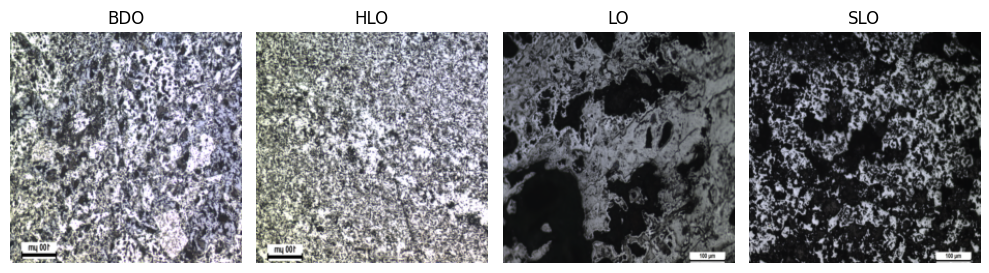

In [ ]:
!pip install timm -q
import torch, timm
from torch import nn, optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

train_ds = datasets.ImageFolder("iron_ore_data/train", transform=train_transform)
val_ds   = datasets.ImageFolder("iron_ore_data/val", transform=val_transform)

train_dl = DataLoader(train_ds, batch_size=4, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=4)

num_classes = len(train_ds.classes)
print("Classes:", train_ds.classes)

# show sample images
def imshow(img, title):
    img = img.numpy().transpose((1,2,0))
    mean = np.array([0.485,0.456,0.406])
    std = np.array([0.229,0.224,0.225])
    img = std * img + mean
    img = np.clip(img,0,1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

images, labels = next(iter(train_dl))
plt.figure(figsize=(10,5))
for i in range(min(4, len(images))):
    plt.subplot(1,4,i+1)
    imshow(images[i], train_ds.classes[labels[i]])
plt.tight_layout()
plt.show()

In [ ]:
def train_and_evaluate(model_name, epochs=10):
    print(f"\n===== Training {model_name} =====")
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for imgs, labels in train_dl:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_dl:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                preds = out.argmax(dim=1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{epochs} - Loss: {total_loss/len(train_dl):.4f} - Val Acc: {val_acc:.2f}%")

    return val_acc

In [ ]:
models_to_try = ['resnet50', 'densenet121', 'swin_tiny_patch4_window7_224']

results = {}
for m in models_to_try:
    acc = train_and_evaluate(m, epochs=10)
    results[m] = acc

print("\n===== FINAL RESULTS =====")
for m, acc in results.items():
    print(f"{m}: {acc:.2f}%")


===== Training resnet50 =====


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Epoch 1/10 - Loss: 1.4037 - Val Acc: 16.67%
Epoch 2/10 - Loss: 1.3985 - Val Acc: 33.33%
Epoch 3/10 - Loss: 1.3872 - Val Acc: 66.67%
Epoch 4/10 - Loss: 1.3860 - Val Acc: 66.67%
Epoch 5/10 - Loss: 1.3532 - Val Acc: 66.67%
Epoch 6/10 - Loss: 1.3570 - Val Acc: 33.33%
Epoch 7/10 - Loss: 1.3671 - Val Acc: 33.33%
Epoch 8/10 - Loss: 1.3231 - Val Acc: 16.67%
Epoch 9/10 - Loss: 1.3275 - Val Acc: 16.67%
Epoch 10/10 - Loss: 1.3172 - Val Acc: 33.33%

===== Training densenet121 =====


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

Epoch 1/10 - Loss: 1.4392 - Val Acc: 16.67%
Epoch 2/10 - Loss: 1.3597 - Val Acc: 0.00%
Epoch 3/10 - Loss: 1.1758 - Val Acc: 0.00%
Epoch 4/10 - Loss: 1.0661 - Val Acc: 33.33%
Epoch 5/10 - Loss: 1.1020 - Val Acc: 33.33%
Epoch 6/10 - Loss: 0.8916 - Val Acc: 33.33%
Epoch 7/10 - Loss: 0.6368 - Val Acc: 33.33%
Epoch 8/10 - Loss: 0.6398 - Val Acc: 33.33%
Epoch 9/10 - Loss: 0.7984 - Val Acc: 66.67%
Epoch 10/10 - Loss: 0.8155 - Val Acc: 66.67%

===== Training swin_tiny_patch4_window7_224 =====


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Epoch 1/10 - Loss: 1.5103 - Val Acc: 66.67%
Epoch 2/10 - Loss: 1.0105 - Val Acc: 66.67%
Epoch 3/10 - Loss: 0.5598 - Val Acc: 66.67%
Epoch 4/10 - Loss: 0.4314 - Val Acc: 50.00%
Epoch 5/10 - Loss: 0.2913 - Val Acc: 83.33%
Epoch 6/10 - Loss: 0.0876 - Val Acc: 66.67%
Epoch 7/10 - Loss: 0.4437 - Val Acc: 83.33%
Epoch 8/10 - Loss: 0.0261 - Val Acc: 50.00%
Epoch 9/10 - Loss: 0.6433 - Val Acc: 83.33%
Epoch 10/10 - Loss: 0.1045 - Val Acc: 83.33%

===== FINAL RESULTS =====
resnet50: 33.33%
densenet121: 66.67%
swin_tiny_patch4_window7_224: 83.33%
